In [16]:
#アヤメのデータ
import numpy as np
import pandas as pd
from sklearn import datasets
irisdata = datasets.load_iris()
X = irisdata.data #特徴量（説明変数）
y = irisdata.target #目的変数 Setosa=0 Versicolor=1 Verginica=2　のダミー
print(irisdata.feature_names) #いったんprintで見てみる
print(irisdata.target_names)

# irisdata.dataを標準化 (特徴量の標準化)
from sklearn.preprocessing import StandardScaler
#irisdata.data #データを確認
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)
#X　#みてみる

#訓練データとテストデータに分ける
from sklearn.model_selection import train_test_split
X = irisdata.data
y = irisdata.target
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, shuffle=True)

#モデルを作成して訓練する　※分類
from sklearn.svm import SVC #サポートベクターマシンというの
classifier = SVC(kernel="linear")

classifier.fit(X_train, y_train) #fitメソッドで学習実行

#期待する性能が出たかを評価
y_pred = classifier.predict(X_test) #テストデータを入れて評価するメソッド

#これで　y_predに分類結果、　y_testにこたえが入った状態。性能を比較する
from sklearn import metrics
print(metrics.accuracy_score(y_test, y_pred)) #性能を評価するメソッド
#実行すると、合致した割合が出る　例：0.933333
#また以下は、混同行列で表示。見方は、対角線上の数値が正解数。
metrics.confusion_matrix(y_test, y_pred)


['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']
1.0


array([[10,  0,  0],
       [ 0,  8,  0],
       [ 0,  0, 12]], dtype=int64)

#### 実習1

In [23]:
#手書き数字の画像の分類
import numpy as np
import pandas as pd

from sklearn import datasets
digits = datasets.load_digits()
print(digits.DESCR) #データセットの詳細表示

X = digits.data
y = digits.target
print(X.shape) #64　は、ピクセル数8×8のモノクロ画像。
print(y.shape)

print(X[0])
print(y[0:50])

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

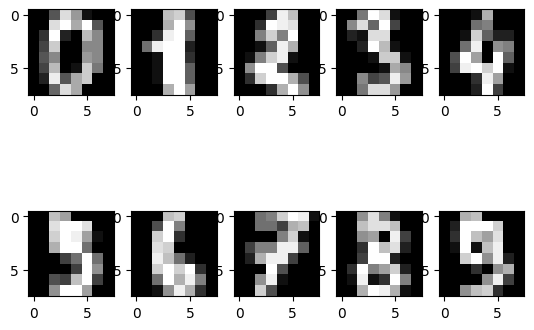

In [24]:
#続き　画像をpltで見てみる
import matplotlib.pyplot as plt
fig = plt.figure()

for i, x in enumerate(X[0:10], 0):
    sp = fig.add_subplot(2, 5, (i + 1))
    sp.imshow(x.reshape(8, 8), cmap = "gray")

In [25]:
#前処理はいらない。すべてのデータが同じスケール。8×8の16段階
#テストデータと訓練データには分ける必要。
# 1800件あるデータのうち1200件をテスト用に。
X_train = X[:1200]
X_test  = X[1200:]
y_train = y[:1200]
y_test  = y[1200:]

In [ ]:
#分類もっるのため今回もSVC。線形分類モデル
from sklearn.svm import SVC
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train)#fitメソッドで学習実行
#↓なんだこれ

SVC(kernel='linear')

In [ ]:
y_pred = classifier.predict(X_test) #predictで分類にかけて
from sklearn import metrics #混同行列でチェック。
print(metrics.confusion_matrix(y_test, y_pred))

[[58  0  0  0  0  0  1  0  0  0]
 [ 0 53  0  0  0  0  1  0  2  5]
 [ 1  0 59  0  0  0  0  0  0  0]
 [ 0  0  0 52  0  1  0  2  7  0]
 [ 1  0  0  0 57  0  0  0  1  2]
 [ 0  0  0  0  0 58  1  0  0  0]
 [ 0  1  0  0  0  0 60  0  0  0]
 [ 0  0  0  0  0  0  0 61  0  0]
 [ 0  1  0  2  1  0  0  1 50  0]
 [ 0  0  0  1  0  2  0  1  1 53]]


In [31]:
#具体的な数値で正答率をみる
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97        59
           1       0.96      0.87      0.91        61
           2       1.00      0.98      0.99        60
           3       0.95      0.84      0.89        62
           4       0.98      0.93      0.96        61
           5       0.95      0.98      0.97        59
           6       0.95      0.98      0.97        61
           7       0.94      1.00      0.97        61
           8       0.82      0.91      0.86        55
           9       0.88      0.91      0.90        58

    accuracy                           0.94       597
   macro avg       0.94      0.94      0.94       597
weighted avg       0.94      0.94      0.94       597



### 課題12：腫瘍の分類.ipynb

In [ ]:
直接ノートへ。